# $\nu_{\tau}$ Investigation in the Dune Collaboration for Advanced Particle Physics Laboratory 2026 - NN Training
Author: Grzegorz Jędrzejowski \
Supervision: prof. Katarzyna Grzelak


# Includes

In [ ]:
import os, sys, importlib
my_home = '/scratch1/gjedrzej/Lab'
os.chdir(my_home) #GJ path
sys.path.append(os.path.join(os.getcwd(), "python"))

In [ ]:
requirements_path = os.path.join(my_home, 'requirements.txt')

%pip install --upgrade pip #Pip 21.3+ is required
%pip install -r {requirements_path}

#you might need to restart the kernel after installing requirements

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

## Seeds for prototyping

In [89]:
np.random.seed(42)
tf.random.set_seed(42)
#there is also one in pd in ml.get_train_val_subsets in shuffle

In [3]:
import analysis.scripts.convert_full_nodebug as kg
importlib.reload(kg)

import analysis.scripts.convert_skwarek as sk
importlib.reload(sk)

import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

import analysis.scripts.ml_functions as ml
importlib.reload(ml)


output_dir = 'analysis/processedData'

if not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)
    print(f"Created directory: {output_dir}")

/scratch1/gjedrzej/.local/lib/python3.9/site-packages/ROOT/__init__.py:5: UserWarning: 
This distribution of ROOT is in alpha stage. Feedback is welcome and appreciated. Feel free to reach out to the user forum for questions and general feedback at https://root-forum.cern.ch or to submit an issue at https://github.com/root-project/root/issues. Do not rely on this distribution for production purposes.

  warnings.warn(
/scratch1/gjedrzej/.local/lib/python3.9/site-packages/cppyy/__init__.py:374: UserWarning: CPyCppyy API not found (tried: /usr/include/site/python3.9); set CPPYY_API_PATH envar to the 'CPyCppyy' API directory to fix
  warnings.warn("CPyCppyy API not found (tried: %s); "


# File Paths

In [4]:
FilePath_all = "/scratch1/gjedrzej/Lab/Generators/data/nu_tau_CC_NC_interactions.gtrac.root"
output_path_all = os.path.join(output_dir, 'data_all_tau.csv')

# Plotting Class Separation Hypothesis before data preprocessing
Histrogramy dla próbek wygenerowanych całościowo (0.5-30 GeV) z rozpadającym się Taonem

In [75]:
df_all = pd.read_csv(output_path_all)
df_legacy=df_all
df_all_CC = df_all[df_all['CCNC'] == 'CC']
df_all_NC = df_all[df_all['CCNC'] == 'NC']

# pf.plot_tau_energy(df_all, ALL=True) confirmed no taons in the dataset

dfs_preprocessed = [df_all, df_all_CC, df_all_NC]

--- [INFO] Nieznane kody PDG w trybie ch_pions: {1000180400.0, 2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie ch_pions: {1000180400.0} ---
--- [INFO] Nieznane kody PDG w trybie ch_pions: {1000180400.0, 2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {1000180400.0, 2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {1000180400.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {1000180400.0, 2000000101.0} ---


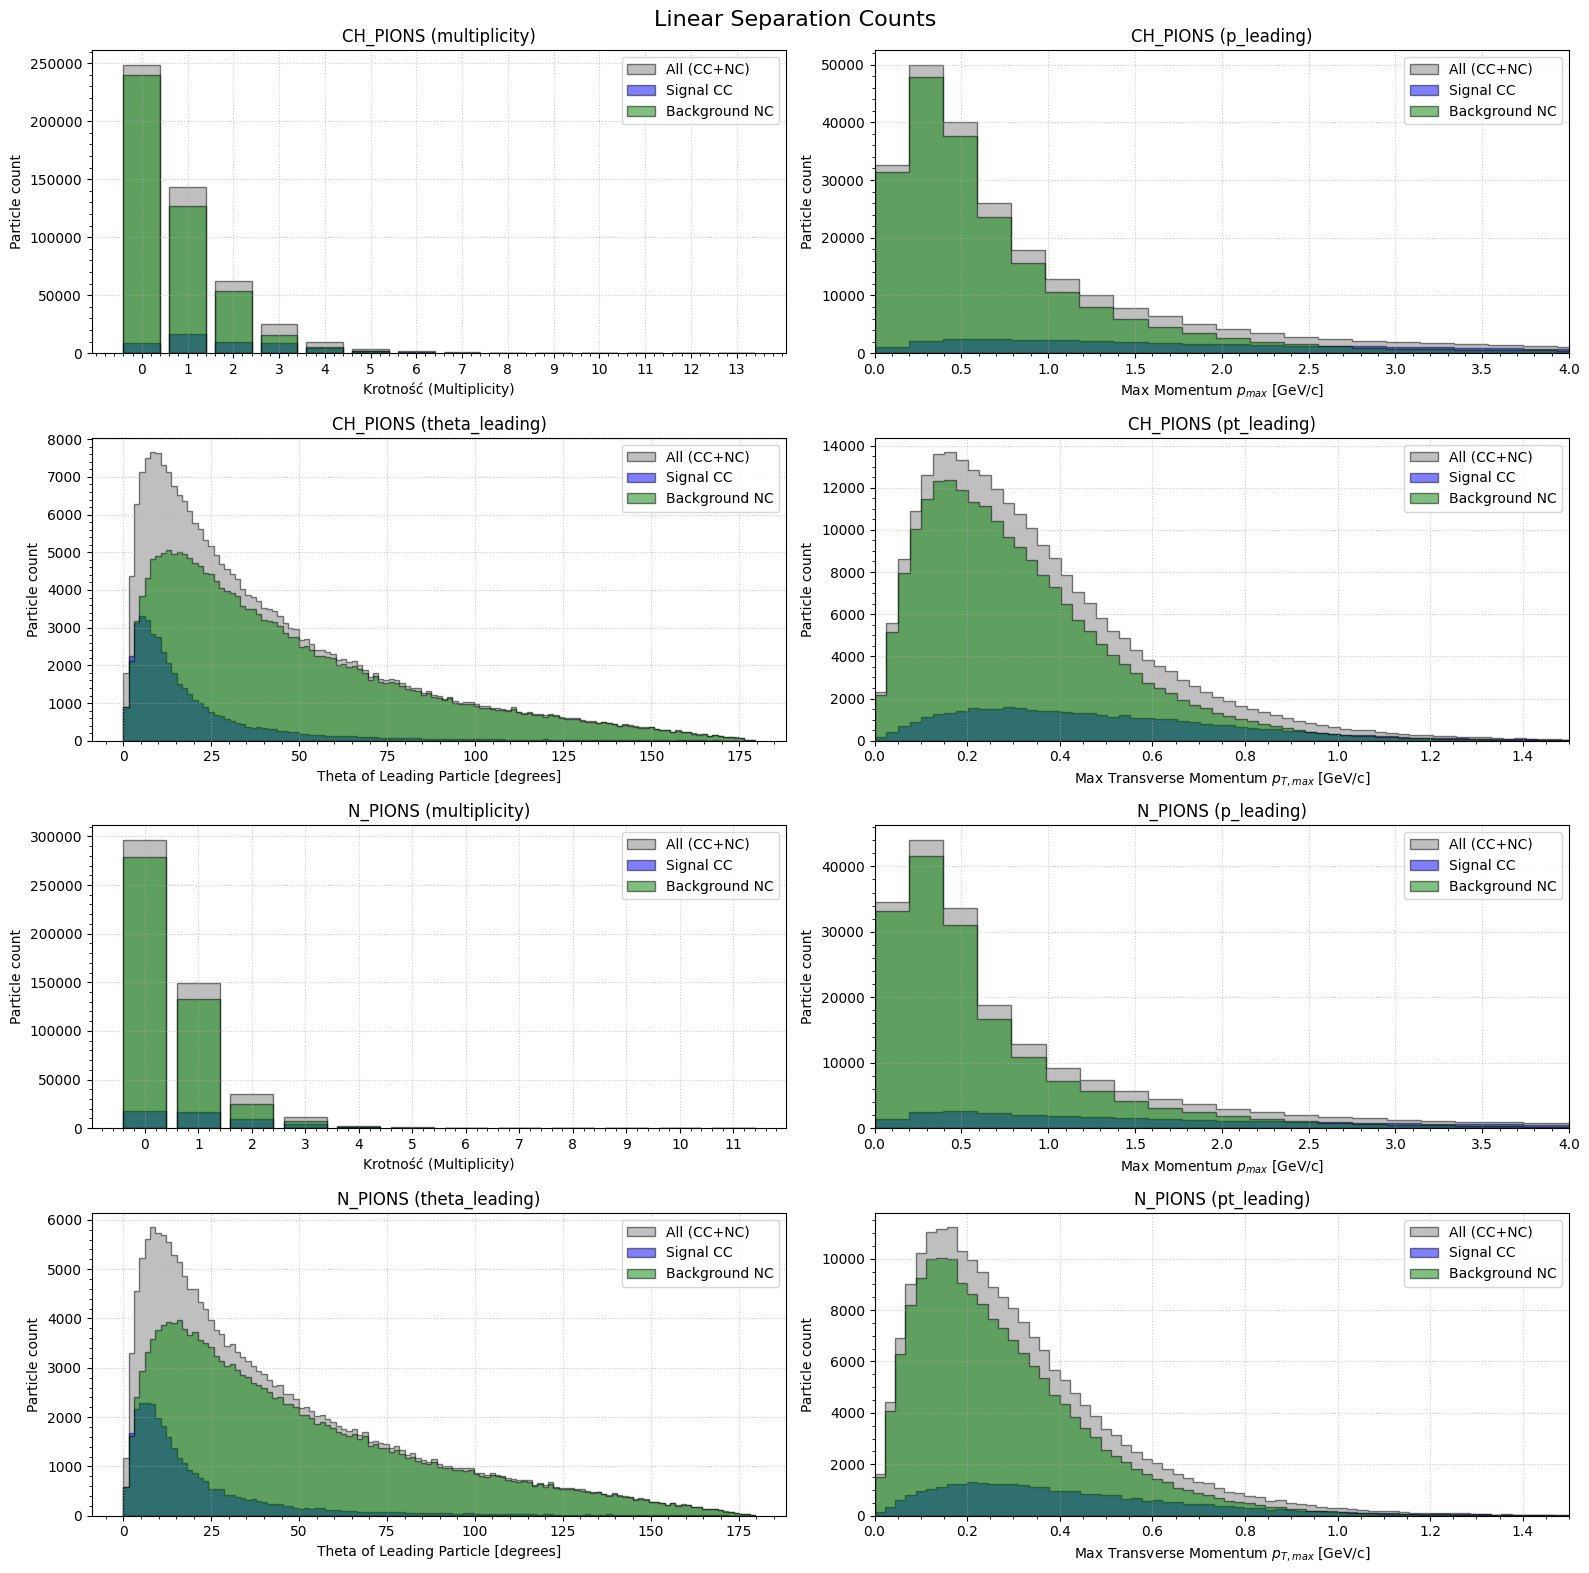

In [40]:
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

fig, axes = plt.subplots(4, 2, figsize=(16, 16))

pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='multiplicity', ax=axes[0, 0], density=False)
pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='p_leading', ax=axes[0, 1], density=False)
axes[0, 1].set_xlim(0, 4) 

pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='theta_leading', ax=axes[1, 0], density=False)
pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='pt_leading', ax=axes[1, 1], density=False)
axes[1, 1].set_xlim(0, 1.5) 

pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='multiplicity', ax=axes[2, 0], density=False)
pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='p_leading', ax=axes[2, 1], density=False)
axes[2, 1].set_xlim(0, 4) 

pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='theta_leading', ax=axes[3, 0], density=False)
pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='pt_leading', ax=axes[3, 1], density=False)
axes[3, 1].set_xlim(0, 1.5) 

plt.suptitle("Linear Separation Counts", fontsize=16)
plt.tight_layout()
plt.show()

--- [INFO] Nieznane kody PDG w trybie ch_pions: {1000180400.0, 2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie ch_pions: {1000180400.0} ---
--- [INFO] Nieznane kody PDG w trybie ch_pions: {1000180400.0, 2000000101.0} ---


--- [INFO] Nieznane kody PDG w trybie n_pions: {1000180400.0, 2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {1000180400.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {1000180400.0, 2000000101.0} ---


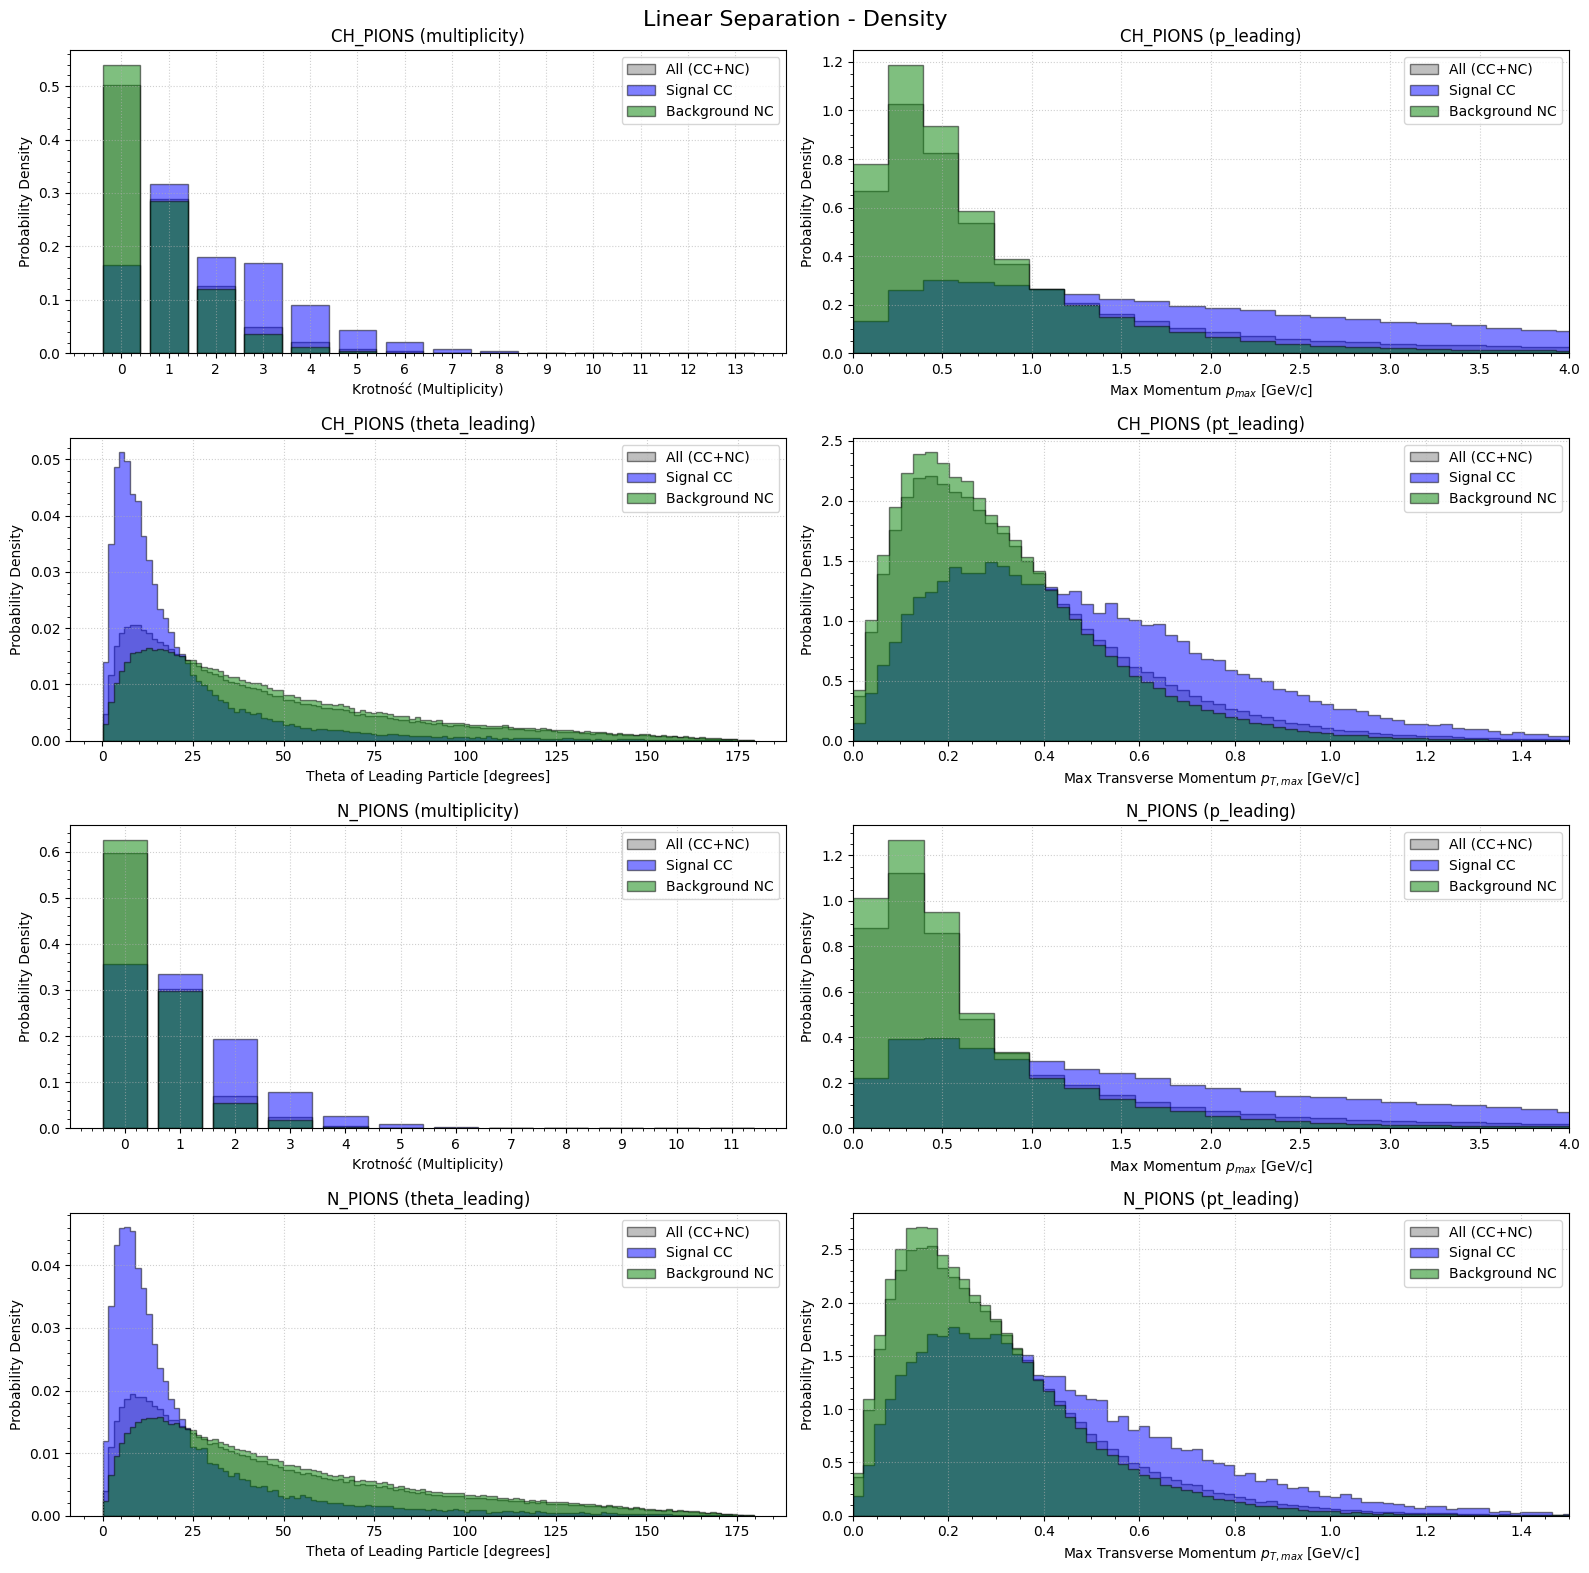

In [41]:
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

fig, axes = plt.subplots(4, 2, figsize=(16, 16))

pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='multiplicity', ax=axes[0, 0], density=True)
pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='p_leading', ax=axes[0, 1], density=True)
axes[0, 1].set_xlim(0, 4) 

pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='theta_leading', ax=axes[1, 0], density=True)
pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='pt_leading', ax=axes[1, 1], density=True)
axes[1, 1].set_xlim(0, 1.5) 

pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='multiplicity', ax=axes[2, 0], density=True)
pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='p_leading', ax=axes[2, 1], density=True)
axes[2, 1].set_xlim(0, 4) 

pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='theta_leading', ax=axes[3, 0], density=True)
pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='pt_leading', ax=axes[3, 1], density=True)
axes[3, 1].set_xlim(0, 1.5) 

plt.suptitle("Linear Separation - Density", fontsize=16)
plt.tight_layout()
plt.show()

## Data Preprocess

In [ ]:
#features:
# ch pions multiplicity, leading p, leading theta, leading pt - 4
# n pions multiplicity, leading p, leading theta - 3

#labels:
# CC vs NC

In [17]:
import analysis.scripts.ml_functions as ml
importlib.reload(ml)
#take the data we analyzed above
FilePath_all = "/scratch1/gjedrzej/Lab/Generators/data/nu_tau_CC_NC_interactions.gtrac.root"
output_path_all = os.path.join(output_dir, 'data_all_tau.csv')
df_all = pd.read_csv(output_path_all)




#the dfs need to be shuffled, later i will need to shuffle when combining samples
df_balanced_train, df_balanced_val = ml.get_train_val_subsets(df_all, cc_per_type=30, nc_per_type=30, val_size=0.2, shuffle=True)
train_data = ml.preProcess_data(df_balanced_train)
val_data = ml.preProcess_data(df_balanced_val)



--- Success! Train: 192 events, Val: 48 events ---
--- [INFO] Nieznane kody PDG w trybie ch_pions: {2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie ch_pions: {2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {2000000101.0} ---


# Plotting Class Separation Hypothesis AFTER data preprocessing
Histrogramy dla próbek wygenerowanych całościowo (0.5-30 GeV) z rozpadającym się Taonem

Text(0.5, 1.0, 'Int type for NC')

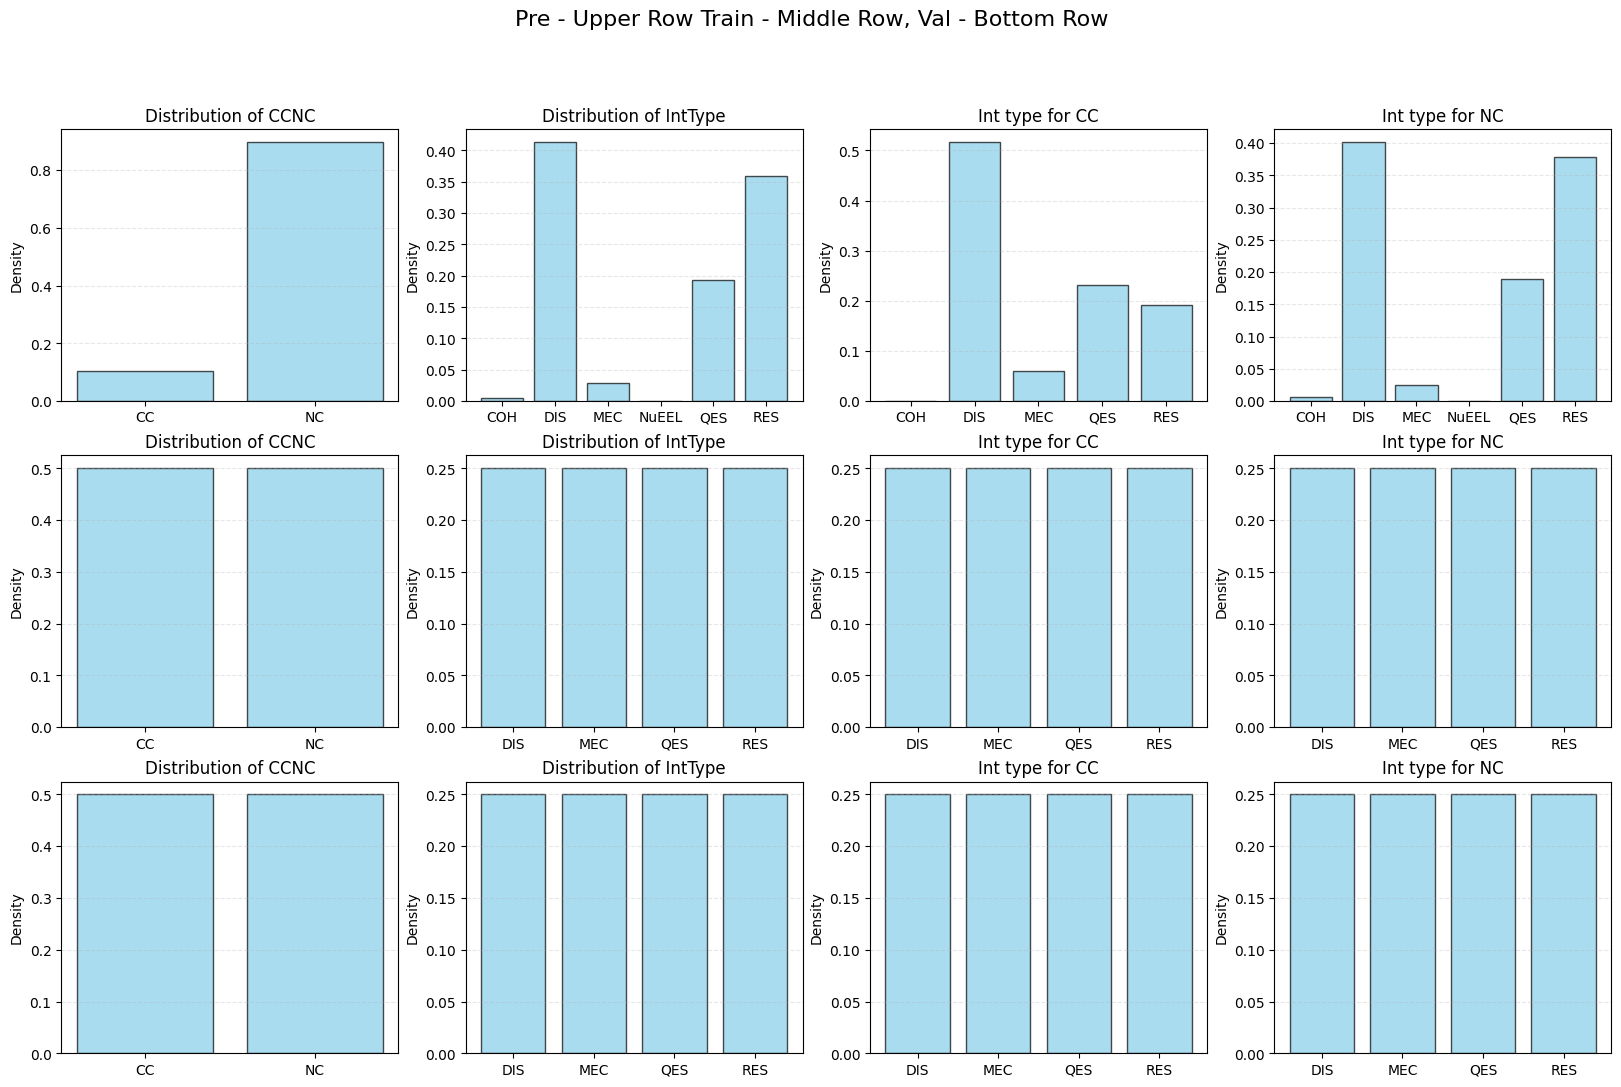

In [77]:
df_all = df_balanced_train
df_all_CC = df_all[df_all['CCNC'] == 'CC']
df_all_NC = df_all[df_all['CCNC'] == 'NC']

dfs_processed = [df_all, df_all_CC, df_all_NC]

fig, axes = plt.subplots(3, 4, figsize=(20, 12))

plt.suptitle("Pre - Upper Row Train - Middle Row, Val - Bottom Row", fontsize=16)

pf.plot_physics_results(df_legacy, column='CCNC', ccnc_filter=None, int_filter=None, ax=axes[0,0], density=True)
pf.plot_physics_results(df_legacy, column='IntType', ccnc_filter=None, int_filter=None, ax=axes[0,1], density=True)
pf.plot_physics_results(df_legacy, column='IntType', ccnc_filter='CC', int_filter=None, ax=axes[0,2], density=True)
axes[0,2].set_title("Int type for CC")
pf.plot_physics_results(df_legacy, column='IntType', ccnc_filter='NC', int_filter=None, ax=axes[0,3], density=True)
axes[0,3].set_title("Int type for NC")

pf.plot_physics_results(df_balanced_train, column='CCNC', ccnc_filter=None, int_filter=None, ax=axes[1,0], density=True)
pf.plot_physics_results(df_balanced_train, column='IntType', ccnc_filter=None, int_filter=None, ax=axes[1,1], density=True)
pf.plot_physics_results(df_balanced_train, column='IntType', ccnc_filter='CC', int_filter=None, ax=axes[1,2], density=True)
axes[1,2].set_title("Int type for CC")
pf.plot_physics_results(df_balanced_train, column='IntType', ccnc_filter='NC', int_filter=None, ax=axes[1,3], density=True)
axes[1,3].set_title("Int type for NC")

pf.plot_physics_results(df_balanced_val, column='CCNC', ccnc_filter=None, int_filter=None, ax=axes[2,0], density=True)
pf.plot_physics_results(df_balanced_val, column='IntType', ccnc_filter=None, int_filter=None, ax=axes[2,1], density=True)
pf.plot_physics_results(df_balanced_val, column='IntType', ccnc_filter='CC', int_filter=None, ax=axes[2,2], density=True)
axes[2,2].set_title("Int type for CC")
pf.plot_physics_results(df_balanced_val, column='IntType', ccnc_filter='NC', int_filter=None, ax=axes[2,3], density=True)
axes[2,3].set_title("Int type for NC")

--- [INFO] Nieznane kody PDG w trybie ch_pions: {2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie ch_pions: {2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie ch_pions: {1000180400.0, 2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie ch_pions: {1000180400.0} ---
--- [INFO] Nieznane kody PDG w trybie ch_pions: {1000180400.0, 2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {1000180400.0, 2000000101.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {1000180400.0} ---
--- [INFO] Nieznane kody PDG w trybie n_pions: {1000180400.0, 2000000101.0} ---


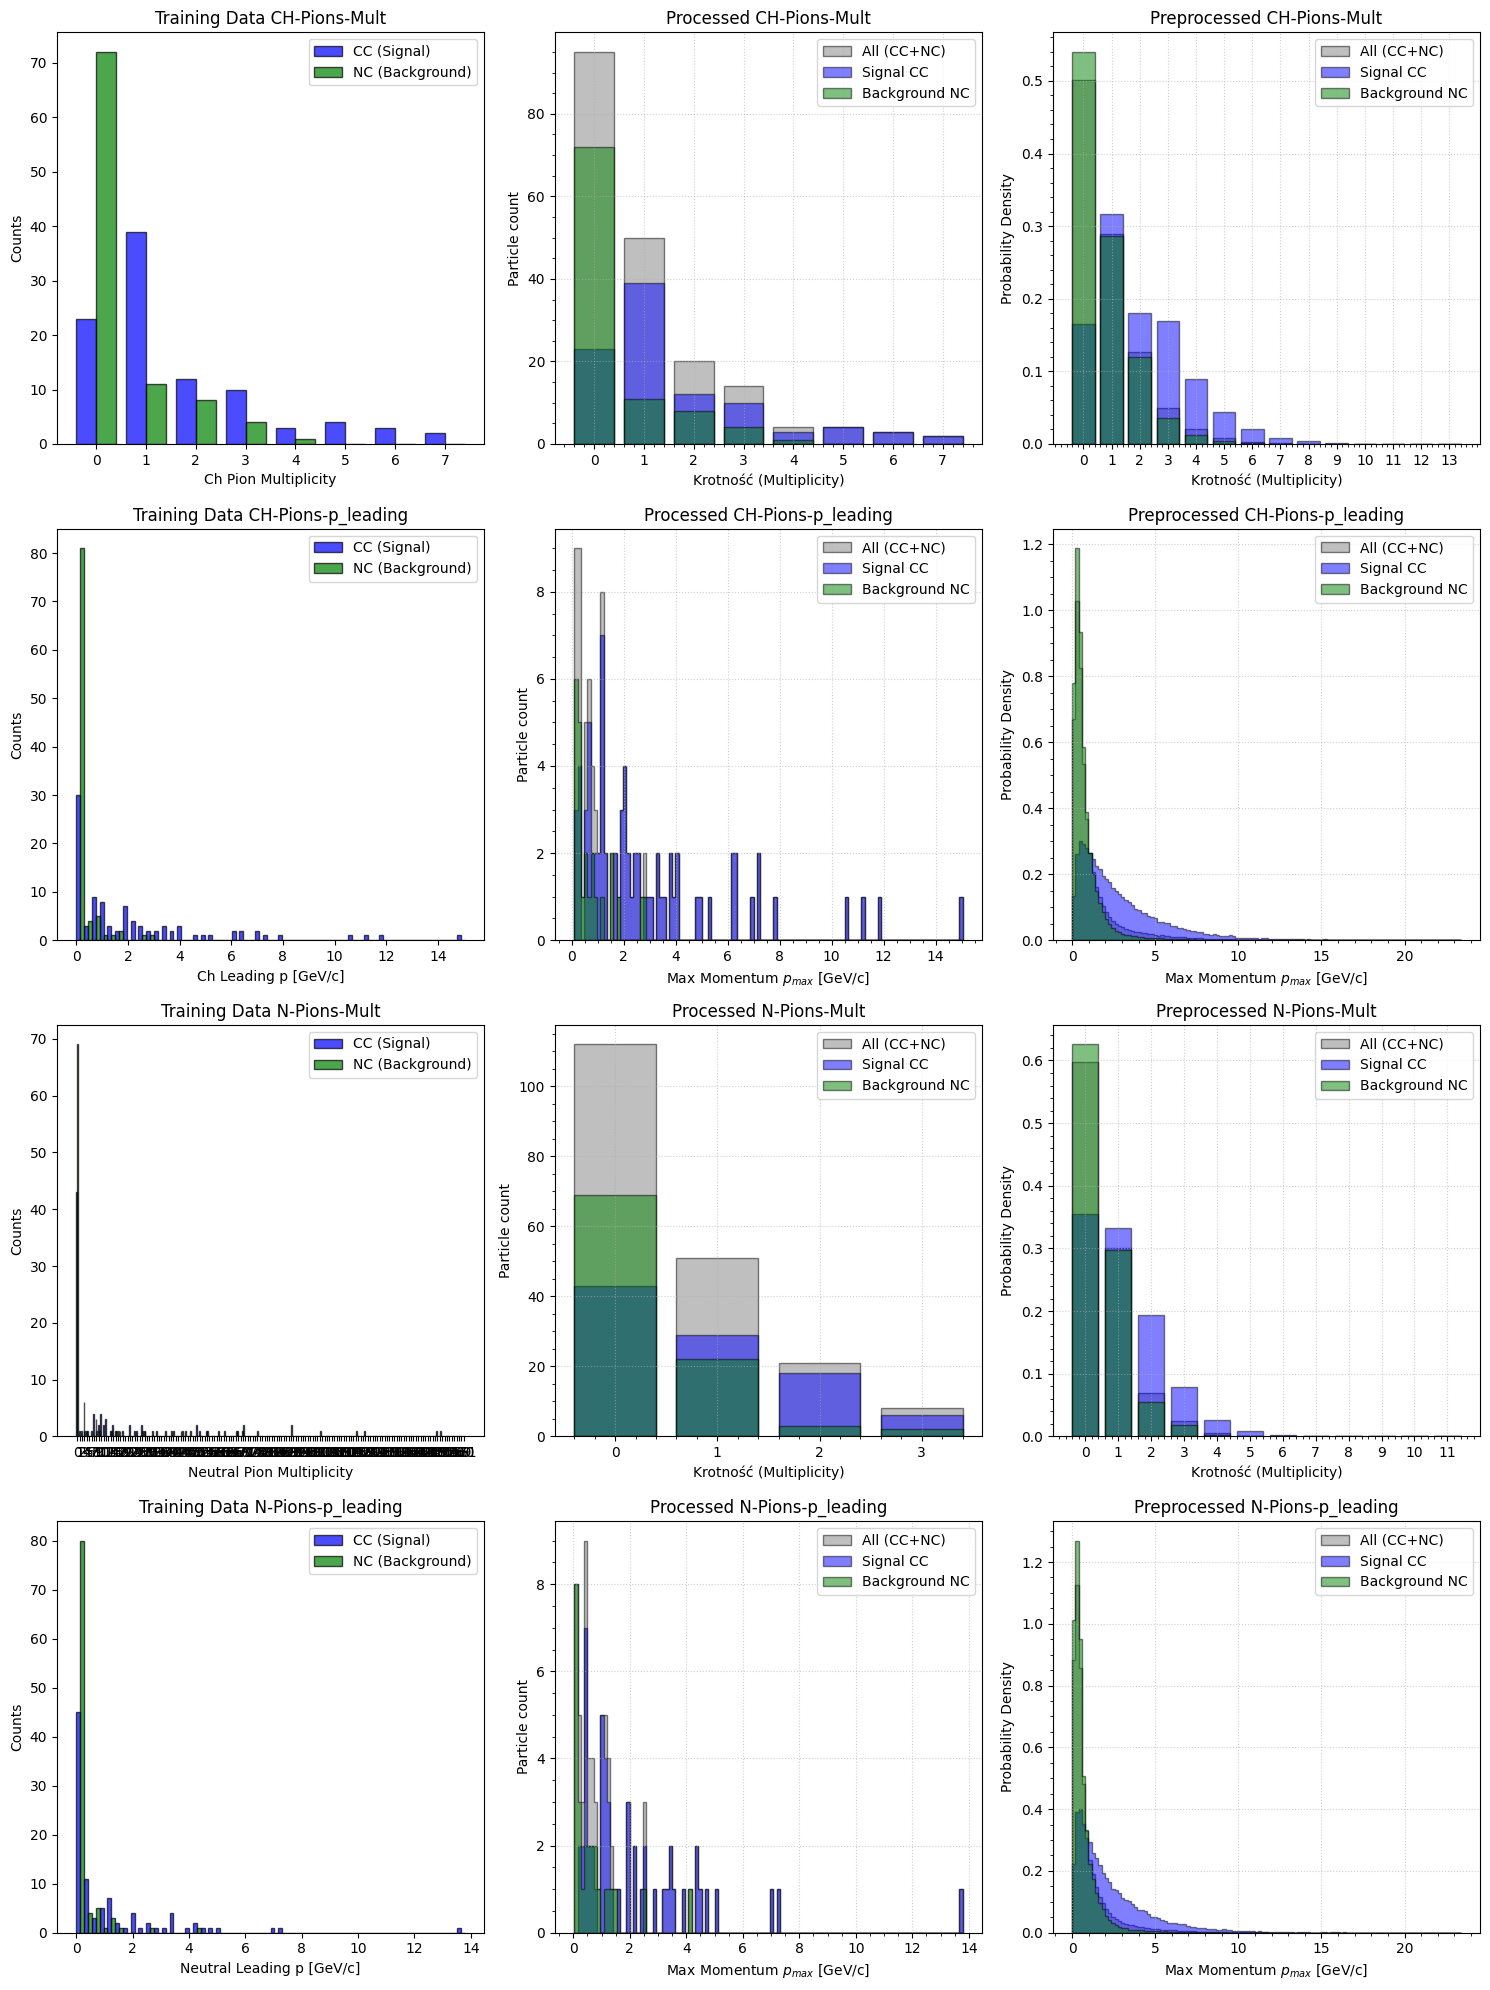

2026-04-28 08:06:34.884072: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-28 08:06:37.747834: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-28 08:06:40.712688: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-28 08:06:42.847044: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [19]:
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)



fig, axes = plt.subplots(4, 3, figsize=(15, 20))

pf.plot_feature_from_dataset(train_data, 0, ax=axes[0, 0]) 
axes[0,0].set_title("Training Data CH-Pions-Mult")    
pf.plot_physics_single_canva(dfs_processed, 'ch_pions', feature='multiplicity', ax=axes[0, 1], density=False)
axes[0,1].set_title("Processed CH-Pions-Mult")    
pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='multiplicity', ax=axes[0, 2], density=True)
axes[0,2].set_title("Preprocessed CH-Pions-Mult")    

pf.plot_feature_from_dataset(train_data, 1, ax=axes[1, 0]) 
axes[1,0].set_title("Training Data CH-Pions-p_leading")    
pf.plot_physics_single_canva(dfs_processed, 'ch_pions', feature='p_leading', ax=axes[1, 1], density=False)
axes[1,1].set_title("Processed CH-Pions-p_leading")    
pf.plot_physics_single_canva(dfs_preprocessed, 'ch_pions', feature='p_leading', ax=axes[1, 2], density=True)
axes[1,2].set_title("Preprocessed CH-Pions-p_leading")    

pf.plot_feature_from_dataset(train_data, 4, ax=axes[2, 0]) # Neutral Multiplicity
axes[2,0].set_title("Training Data N-Pions-Mult")
pf.plot_physics_single_canva(dfs_processed, 'n_pions', feature='multiplicity', ax=axes[2, 1], density=False)
axes[2,1].set_title("Processed N-Pions-Mult")
pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='multiplicity', ax=axes[2, 2], density=True)
axes[2,2].set_title("Preprocessed N-Pions-Mult")

pf.plot_feature_from_dataset(train_data, 5, ax=axes[3, 0]) # Neutral Leading p
axes[3,0].set_title("Training Data N-Pions-p_leading")
pf.plot_physics_single_canva(dfs_processed, 'n_pions', feature='p_leading', ax=axes[3, 1], density=False)
axes[3,1].set_title("Processed N-Pions-p_leading")
pf.plot_physics_single_canva(dfs_preprocessed, 'n_pions', feature='p_leading', ax=axes[3, 2], density=True)
axes[3,2].set_title("Preprocessed N-Pions-p_leading")

# axes[3, 1].axis('off')
plt.tight_layout()
plt.show()

## Model

In [8]:
#very simple 1dCNN

model_1dCNN = tf.keras.Sequential([
    tf.keras.Input(shape=(7, 1)),
    tf.keras.layers.BatchNormalization(), #the data is not normalized
    tf.keras.layers.Conv1D(filters=16, kernel_size=3, activation='relu'),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(1, activation='sigmoid')
], name='1dCNN')

model_1dCNN.summary()   


Model: "1dCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 7, 1)           │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 5, 16)          │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85 (340.00 B)

 Trainable params: 83 (332.00 B)

 Non-trainable params: 2 (8.00 B)

## Training

In [10]:
# train CNN
# we need validation set later, now lets use train test split

#add checkpoints
#add model saving 
#and modelo loading
#add comet

#####
nEpochs = 20
initial_learning_rate = 3E-4
callback = []

model_1dCNN.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=initial_learning_rate),
              loss='binary_crossentropy')

In [ ]:
#add checkpoints
#add comet

In [13]:
history = model_1dCNN.fit(
    train_data,
    validation_data=val_data,
    epochs=nEpochs,
    callbacks=callback,
    verbose=1
)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.7066 - val_loss: 1.0733
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7198 - val_loss: 0.9200
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7179 - val_loss: 0.8559
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7014 - val_loss: 0.8205
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7060 - val_loss: 0.7967
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6978 - val_loss: 0.7800
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7032 - val_loss: 0.7673
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6959 - val_loss: 0.7572
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7098 - val_loss: 0.7487
Epoch 10/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7092 - val_loss: 0.7419
Epoch 11/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7024 - val_loss: 0.7362
Epoch 12/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7023 - val_loss: 0.7314
Epoch 13/20


## Save model

In [35]:
os.makedirs("models", exist_ok=True)
path = "models/1DCNN.keras"
model_1dCNN.save(path.format(epoch=nEpochs))

print(f"Model saved successfully to {path.format(epoch=nEpochs)}")

Model saved successfully to models/1DCNN.keras


## Load Model

In [11]:
#wczytanie modelu
nEpochsSaved = nEpochs

checkpoint_path = "models/1DCNN.keras"
model_load_ae = tf.keras.models.load_model(checkpoint_path.format(epoch=nEpochsSaved))

model_load_ae.evaluate(val_data)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7326  


0.7485397458076477

## Evaluation

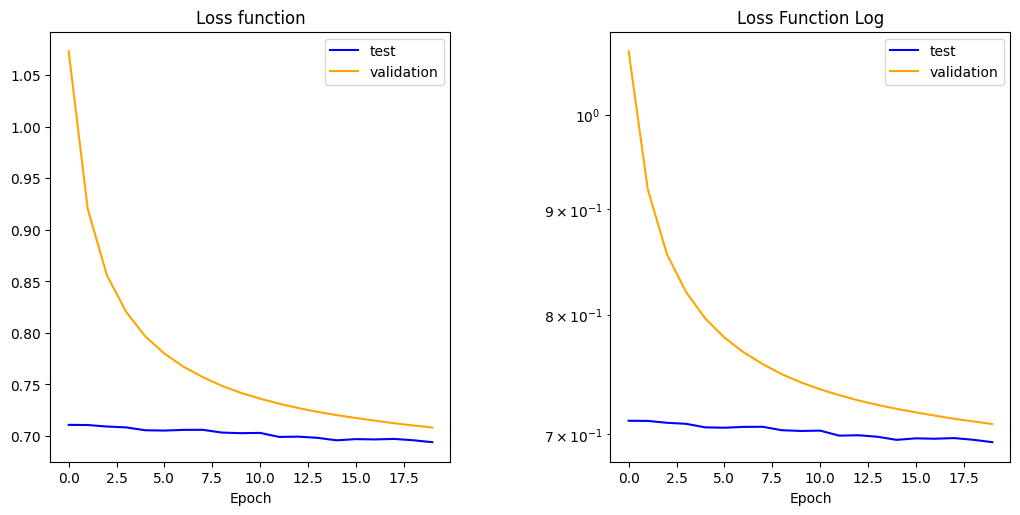

In [15]:
# eval training 

#add plotting podklas
# add CM and other metrics

import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

pf.plotTrainHistory(history)

In [20]:
# 1. Get predictions and flatten them to 1D
train_preds = model_1dCNN.predict(train_data).flatten()
val_preds = model_1dCNN.predict(val_data).flatten()

df_balanced_train['Prob_is_CC'] = train_preds
df_balanced_val['Prob_is_CC'] = val_preds

# 3. Decision: 1 = Predicted CC, 0 = Predicted NC
df_balanced_train['NN_Decision_CC'] = (train_preds > 0.5).astype(int)
df_balanced_val['NN_Decision_CC'] = (val_preds > 0.5).astype(int)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


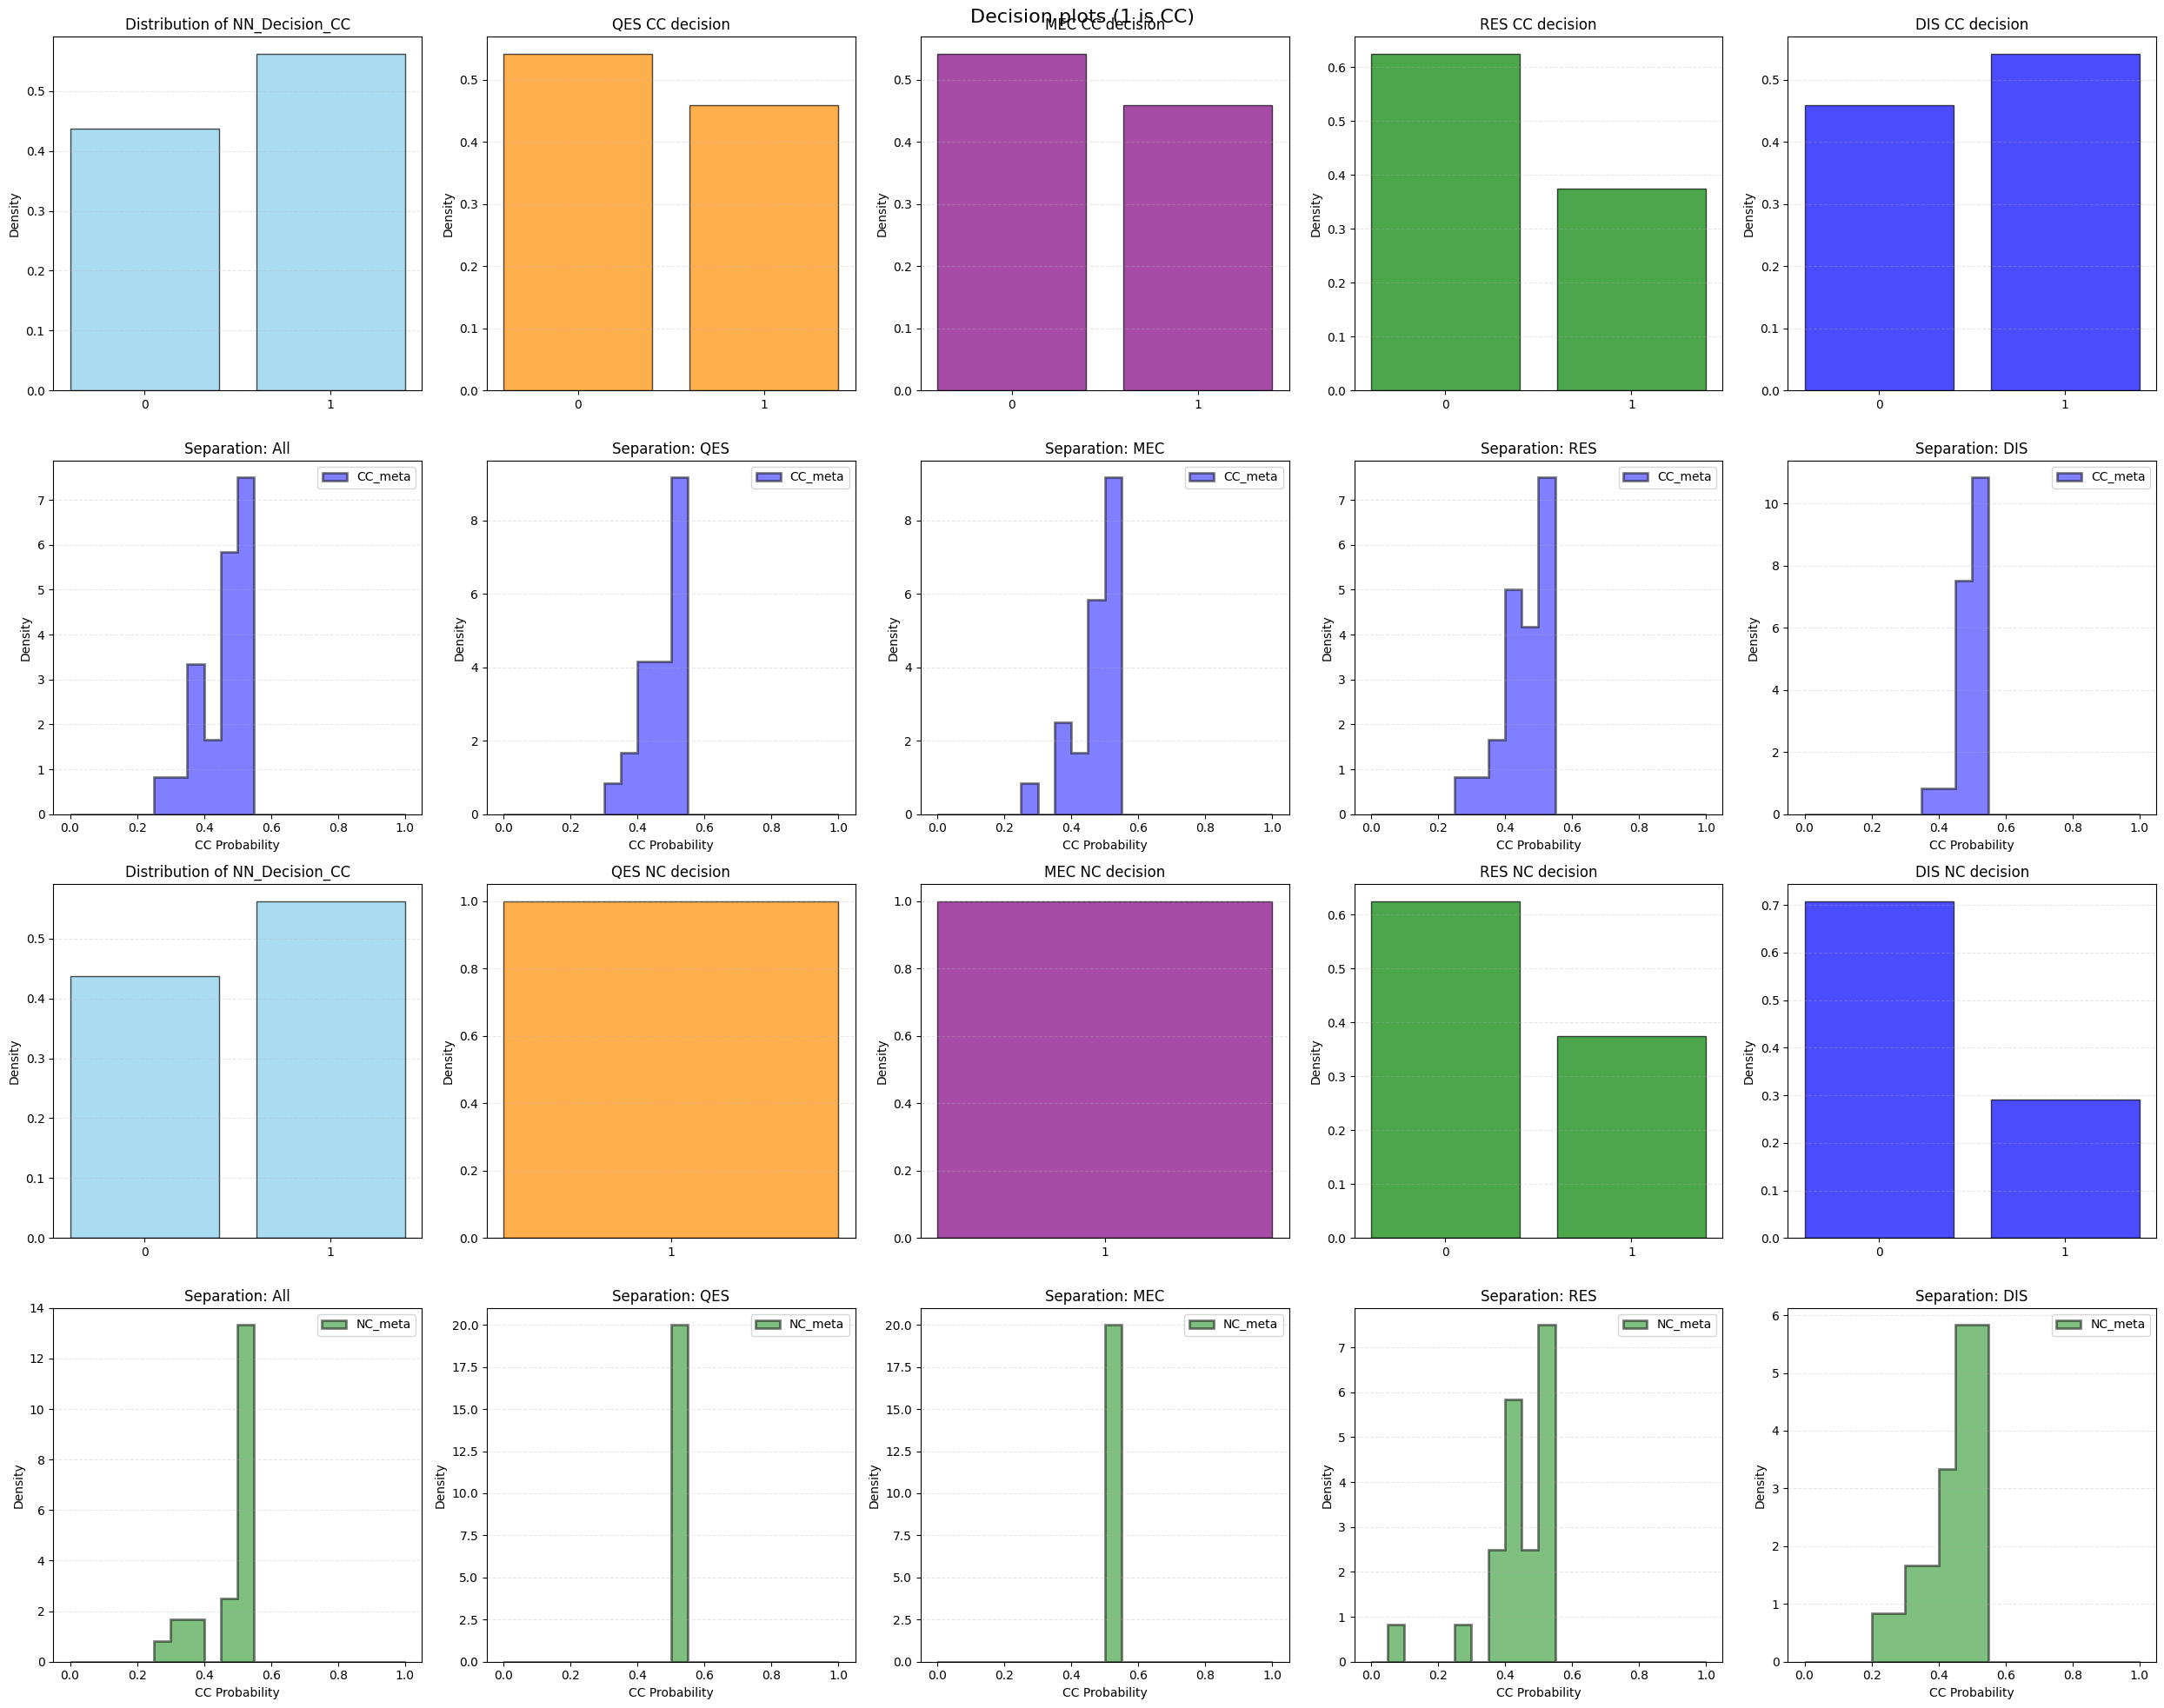

In [84]:
import analysis.scripts.plotting_functions as pf
importlib.reload(pf)

#training before after eval before after (4 cokumns), ccnn, int type (2 rows)
fig, axes = plt.subplots(4, 5, figsize=(25, 20))

plt.suptitle("Decision plots (1 is CC)", fontsize=16)

pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter=None, int_filter=None, ax=axes[0,0], density=True)
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter='CC', int_filter='QES', ax=axes[0,1], density=True, color='darkorange')
axes[0,1].set_title("QES CC decision")
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter='CC', int_filter='MEC', ax=axes[0,2], density=True, color='purple')
axes[0,2].set_title("MEC CC decision")
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter='CC', int_filter='RES', ax=axes[0,3], density=True, color='green')
axes[0,3].set_title("RES CC decision")
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter='CC', int_filter='DIS', ax=axes[0,4], density=True, color='blue')
axes[0,4].set_title("DIS CC decision")


pf.plot_physics_results(df_balanced_val, column='Prob_is_CC', ccnc_filter='CC', int_filter=None, ax=axes[1,0], density=True, bins=None)
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter='CC', int_filter='QES', ax=axes[1,1], density=True, color='darkorange')
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter='CC', int_filter='MEC', ax=axes[1,2], density=True, color='purple')
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter='CC', int_filter='RES', ax=axes[1,3], density=True, color='green')
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter='CC', int_filter='DIS', ax=axes[1,4], density=True, color='blue')


pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter=None, int_filter=None, ax=axes[2,0], density=True)
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter='NC', int_filter='QES', ax=axes[2,1], density=True, color='darkorange')
axes[2,1].set_title("QES NC decision")
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter='NC', int_filter='MEC', ax=axes[2,2], density=True, color='purple')
axes[2,2].set_title("MEC NC decision")
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter='NC', int_filter='RES', ax=axes[2,3], density=True, color='green')
axes[2,3].set_title("RES NC decision")
pf.plot_physics_results(df_balanced_train, column='NN_Decision_CC', ccnc_filter='NC', int_filter='DIS', ax=axes[2,4], density=True, color='blue')
axes[2,4].set_title("DIS NC decision")


pf.plot_physics_results(df_balanced_val, column='Prob_is_CC', ccnc_filter='NC', int_filter=None, ax=axes[3,0], density=True, bins=None)
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter='NC', int_filter='QES', ax=axes[3,1], density=True, color='darkorange')
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter='NC', int_filter='MEC', ax=axes[3,2], density=True, color='purple')
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter='NC', int_filter='RES', ax=axes[3,3], density=True, color='green')
pf.plot_physics_results(df_balanced_train, column='Prob_is_CC', ccnc_filter='NC', int_filter='DIS', ax=axes[3,4], density=True, color='blue')


plt.tight_layout()


In [ ]:
#CM and add metrics